# Clasificación supervisada
## Comparación de representaciones tiempo-frecuencia: STFT vs CWT

Este notebook implementa la etapa final del proyecto: entrenar y evaluar
modelos de clasificación supervisada sobre los datasets de features extraídos
en los notebooks anteriores, con el objetivo de determinar qué representación
tiempo-frecuencia produce features de mayor utilidad predictiva.

---

## Contexto: lo que sabemos antes de clasificar

El análisis estadístico del notebook 05 estableció los siguientes hallazgos,
que informan directamente las decisiones de diseño de este notebook:

1. **La CWT supera a la STFT en las cuatro métricas de discriminabilidad**
   (Cohen's $d$, Mann-Whitney, FDR y Mutual Information), con una ventaja
   aproximada del doble en FDR y MI.

2. **La ventaja de la CWT es topográficamente anómala:** los canales más
   discriminativos son frontales (F7, AF3) y temporales (T7, T8), no los
   occipitales y parietales (O1, O2, P7, P8) donde el ritmo alfa debería
   predominar. Esto sugiere que la CWT es más sensible a artefactos de
   origen ocular y muscular que la STFT.

3. **La entropía espectral es degenerada en CWT** (CV = 1.5%, varianza casi
   nula), por lo que no aportará poder discriminativo en esa técnica.

4. **El centro de gravedad (`cog`)** es la feature más robusta y
   fisiológicamente coherente en ambas técnicas.

---

## Decisiones de diseño

### Clasificadores seleccionados

Se usan tres clasificadores complementarios, en lugar de uno solo, para que
los resultados sean robustos ante la elección del modelo:

| Clasificador | Justificación |
|---|---|
| Regresión Logística | Baseline lineal. Si los otros lo superan significativamente, el problema tiene estructura no lineal |
| SVM (kernel RBF) | Robusto con muestras pequeñas y alta dimensión. Maneja relaciones no lineales mediante el parámetro C |
| Random Forest | Maneja multicolinealidad entre canales naturalmente. Entrega importancia de features — permite validar si O1/O2 dominan o no |

### Split de datos: temporal, no aleatorio

Las 236 ventanas tienen 75% de solapamiento — ventanas consecutivas
comparten 1.5 s de señal y son casi idénticas. Un split aleatorio
pondría muestras prácticamente duplicadas en train y test a la vez,
produciendo data leakage e inflando artificialmente el accuracy.

La solución es un **split temporal por bloques**:

> Ventanas   1 – 188  (~80% del registro) → entrenamiento  
> Ventanas 189 – 236  (~20% del registro) → test

Este esquema garantiza que el modelo se evalúa sobre señal que no vio
durante el entrenamiento, respetando la estructura temporal de los datos.

### Escalado

Se aplica `StandardScaler` por separado a STFT y CWT:
- Ajustado **solo sobre el conjunto de entrenamiento** (para no filtrar
  información del test al train).
- Aplicado luego al test.
- Las escalas de STFT y CWT no se mezclan.

### Dos configuraciones de features

Dada la topografía anómala detectada en el notebook 05, se evalúan dos
configuraciones:

**Config A — Todos los canales (56 features):** permite al clasificador
usar cualquier canal, incluyendo los frontales y temporales más
discriminativos según el análisis estadístico.

**Config B — Solo canales relevantes para el alfa (16 features):** restringe
el análisis a O1, O2, P7 y P8 — los cuatro electrodos occipitales y
parietales donde el ritmo alfa debería predominar fisiológicamente.

La comparación entre ambas configuraciones responde una pregunta
metodológica clave: **¿la ventaja de la CWT se mantiene cuando se
restringe a los canales fisiológicamente relevantes, o desaparece porque
dependía de los artefactos en canales frontales y temporales?**

### Métricas de evaluación

Con clases ligeramente desbalanceadas (128 ojos abiertos vs 108 ojos
cerrados) se reportan:
- **Accuracy:** proporción de predicciones correctas.
- **F1-score macro:** promedio del F1 de cada clase, trata ambas clases
  por igual independientemente de su frecuencia.
- **ROC-AUC:** área bajo la curva ROC, mide la capacidad de separación
  independientemente del umbral de decisión.
- **Matriz de confusión:** muestra errores específicos por clase.

---

## Estructura del notebook

**Sección 1:** preparación de datos — split temporal y escalado.

**Sección 2:** entrenamiento y evaluación — 3 clasificadores × 2 técnicas
× 2 configuraciones de features = 12 combinaciones evaluadas. Tabla de
resultados comparativa.

**Sección 3:** importancia de features — análisis del Random Forest para
determinar qué canales dominan realmente la clasificación y si coinciden
con la topografía esperada del ritmo alfa.

**Sección 4:** síntesis y conclusiones — ¿la CWT produce mayor accuracy
que la STFT? ¿Es consistente entre clasificadores y configuraciones?
¿Qué explica los resultados?

# Sección 1: Preparación de Datos

Split temporal sin data leakage, selección de configuraciones de features, y escalado.

In [1]:
# Sección 1: Preparación de Datos
## Cargar datasets tablulares

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import warnings

# Cargar features STFT y CWT
features_stft = pd.read_csv('data/features/features_stft.csv')
features_cwt = pd.read_csv('data/features/features_cwt.csv')

# Extraer labels
y_stft = features_stft['label'].values
y_cwt = features_cwt['label'].values

# Extraer features (todas las columnas excepto 'label')
X_stft = features_stft.drop('label', axis=1).values
X_cwt = features_cwt.drop('label', axis=1).values

print(f"Shape STFT: {X_stft.shape}")
print(f"Shape CWT: {X_cwt.shape}")
print(f"Labels STFT: {np.bincount(y_stft)}")
print(f"Labels CWT: {np.bincount(y_cwt)}")
print(f"\nNombres de features ({len(features_stft.columns)-1}):")
print(features_stft.columns[:-1].tolist())

Shape STFT: (236, 56)
Shape CWT: (236, 56)
Labels STFT: [128 108]
Labels CWT: [128 108]

Nombres de features (56):
['AF3_alpha_abs', 'AF3_alpha_rel', 'AF3_entropy', 'AF3_cog', 'F7_alpha_abs', 'F7_alpha_rel', 'F7_entropy', 'F7_cog', 'F3_alpha_abs', 'F3_alpha_rel', 'F3_entropy', 'F3_cog', 'FC5_alpha_abs', 'FC5_alpha_rel', 'FC5_entropy', 'FC5_cog', 'T7_alpha_abs', 'T7_alpha_rel', 'T7_entropy', 'T7_cog', 'P7_alpha_abs', 'P7_alpha_rel', 'P7_entropy', 'P7_cog', 'O1_alpha_abs', 'O1_alpha_rel', 'O1_entropy', 'O1_cog', 'O2_alpha_abs', 'O2_alpha_rel', 'O2_entropy', 'O2_cog', 'P8_alpha_abs', 'P8_alpha_rel', 'P8_entropy', 'P8_cog', 'T8_alpha_abs', 'T8_alpha_rel', 'T8_entropy', 'T8_cog', 'FC6_alpha_abs', 'FC6_alpha_rel', 'FC6_entropy', 'FC6_cog', 'F4_alpha_abs', 'F4_alpha_rel', 'F4_entropy', 'F4_cog', 'F8_alpha_abs', 'F8_alpha_rel', 'F8_entropy', 'F8_cog', 'AF4_alpha_abs', 'AF4_alpha_rel', 'AF4_entropy', 'AF4_cog']


In [2]:
## Split temporal por bloques (respeta estructura temporal y balance de clases)

n_samples = X_stft.shape[0]
block_size = 30  # Bloques de 30 muestras

# Crear índices de bloques
block_indices = np.arange(n_samples)
block_numbers = block_indices // block_size  # Asignar a bloques

# Bloques pares → train, bloques impares → test
# (respeta estructura temporal y evita data leakage)
train_mask = (block_numbers % 2 == 0)
test_mask = (block_numbers % 2 == 1)

train_indices = np.where(train_mask)[0]
test_indices = np.where(test_mask)[0]

print(f"Split temporal por bloques (tamaño bloque = {block_size}):")
print(f"  Bloques pares (0, 2, 4, ...) → train")
print(f"  Bloques impares (1, 3, 5, ...) → test")
print(f"\nTotal de muestras: {n_samples}")
print(f"Número de bloques: {(n_samples + block_size - 1) // block_size}")
print(f"Train: {len(train_indices)} muestras")
print(f"Test: {len(test_indices)} muestras\n")

# Split STFT
X_stft_train = X_stft[train_indices]
X_stft_test = X_stft[test_indices]
y_stft_train = y_stft[train_indices]
y_stft_test = y_stft[test_indices]

# Split CWT
X_cwt_train = X_cwt[train_indices]
X_cwt_test = X_cwt[test_indices]
y_cwt_train = y_cwt[train_indices]
y_cwt_test = y_cwt[test_indices]

print(f"STFT Train: {X_stft_train.shape}, Test: {X_stft_test.shape}")
print(f"CWT Train: {X_cwt_train.shape}, Test: {X_cwt_test.shape}")
print(f"\nDistribución de labels:")
print(f"STFT Train: {np.bincount(y_stft_train)} (clase 0: {np.sum(y_stft_train==0)/len(y_stft_train):.1%})")
print(f"STFT Test: {np.bincount(y_stft_test)} (clase 0: {np.sum(y_stft_test==0)/len(y_stft_test):.1%})")

Split temporal por bloques (tamaño bloque = 30):
  Bloques pares (0, 2, 4, ...) → train
  Bloques impares (1, 3, 5, ...) → test

Total de muestras: 236
Número de bloques: 8
Train: 120 muestras
Test: 116 muestras

STFT Train: (120, 56), Test: (116, 56)
CWT Train: (120, 56), Test: (116, 56)

Distribución de labels:
STFT Train: [55 65] (clase 0: 45.8%)
STFT Test: [73 43] (clase 0: 62.9%)


In [3]:
## Definir configuraciones de features

# Config A: Todos los canales (14 canales × 4 features = 56 features)
canales_todos = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 
                 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']
features_por_canal = ['alpha_abs', 'alpha_rel', 'entropy', 'cog']

# Config B: Solo canales occipitales y parietales (O1, O2, P7, P8)
canales_alfa = ['O1', 'O2', 'P7', 'P8']

# Obtener índices de features para ambas configuraciones
feature_names = features_stft.columns[:-1].tolist()

def get_feature_indices(feature_names, canales):
    """Obtener índices de features para ciertos canales"""
    indices = []
    for canal in canales:
        for feat in features_por_canal:
            col_name = f"{canal}_{feat}"
            if col_name in feature_names:
                indices.append(feature_names.index(col_name))
    return indices

idx_config_a = get_feature_indices(feature_names, canales_todos)  # Todos
idx_config_b = get_feature_indices(feature_names, canales_alfa)   # Solo alfa

print(f"Config A (todos los canales): {len(idx_config_a)} features")
print(f"Config B (solo canales alfa): {len(idx_config_b)} features")

# Crear datasets para ambas configuraciones
X_stft_train_a, X_stft_test_a = X_stft_train[:, idx_config_a], X_stft_test[:, idx_config_a]
X_stft_train_b, X_stft_test_b = X_stft_train[:, idx_config_b], X_stft_test[:, idx_config_b]

X_cwt_train_a, X_cwt_test_a = X_cwt_train[:, idx_config_a], X_cwt_test[:, idx_config_a]
X_cwt_train_b, X_cwt_test_b = X_cwt_train[:, idx_config_b], X_cwt_test[:, idx_config_b]

print(f"\nShapes después de aplicar configuraciones:")
print(f"STFT Config A: Train {X_stft_train_a.shape}, Test {X_stft_test_a.shape}")
print(f"STFT Config B: Train {X_stft_train_b.shape}, Test {X_stft_test_b.shape}")
print(f"CWT Config A: Train {X_cwt_train_a.shape}, Test {X_cwt_test_a.shape}")
print(f"CWT Config B: Train {X_cwt_train_b.shape}, Test {X_cwt_test_b.shape}")

Config A (todos los canales): 56 features
Config B (solo canales alfa): 16 features

Shapes después de aplicar configuraciones:
STFT Config A: Train (120, 56), Test (116, 56)
STFT Config B: Train (120, 16), Test (116, 16)
CWT Config A: Train (120, 56), Test (116, 56)
CWT Config B: Train (120, 16), Test (116, 16)


In [4]:
## Escalado con StandardScaler

# Crear escaladores por separado para STFT y CWT
scalers = {}

# Función auxiliar para escalar
def scale_data(X_train, X_test, scale_name):
    """Escalar datos usando StandardScaler ajustado solo en train"""
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    scalers[scale_name] = scaler
    return X_train_scaled, X_test_scaled

# Escalar STFT Config A
X_stft_train_a_scaled, X_stft_test_a_scaled = scale_data(
    X_stft_train_a, X_stft_test_a, 'stft_a'
)

# Escalar STFT Config B
X_stft_train_b_scaled, X_stft_test_b_scaled = scale_data(
    X_stft_train_b, X_stft_test_b, 'stft_b'
)

# Escalar CWT Config A
X_cwt_train_a_scaled, X_cwt_test_a_scaled = scale_data(
    X_cwt_train_a, X_cwt_test_a, 'cwt_a'
)

# Escalar CWT Config B
X_cwt_train_b_scaled, X_cwt_test_b_scaled = scale_data(
    X_cwt_train_b, X_cwt_test_b, 'cwt_b'
)

print("✓ Datos escalados correctamente")
print(f"\nEstadisticas después del escalado (media, std en train escalado):")
print(f"STFT Config A - Media: {X_stft_train_a_scaled.mean():.4f}, Std: {X_stft_train_a_scaled.std():.4f}")
print(f"CWT Config A - Media: {X_cwt_train_a_scaled.mean():.4f}, Std: {X_cwt_train_a_scaled.std():.4f}")

✓ Datos escalados correctamente

Estadisticas después del escalado (media, std en train escalado):
STFT Config A - Media: -0.0000, Std: 1.0000
CWT Config A - Media: -0.0000, Std: 1.0000


# Sección 2: Entrenamiento y Evaluación de Clasificadores

Se entrenarán 3 clasificadores (Logistic Regression, SVM RBF, Random Forest) sobre 2 técnicas (STFT, CWT) en 2 configuraciones de features (A: todos los canales, B: solo alfa).

Total: 3 × 2 × 2 = 12 combinaciones a evaluar.

In [5]:
## Definir clasificadores

# Diccionario de clasificadores con sus parámetros
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', C=1.0, probability=True, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
}

# Función para entrenar y evaluar
def train_and_evaluate(X_train, X_test, y_train, y_test, model):
    """Entrenar modelo y retornar métricas de evaluación"""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else np.nan
    cm = confusion_matrix(y_test, y_pred)
    
    return {
        'model': model,
        'accuracy': accuracy,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'confusion_matrix': cm,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

print("✓ Clasificadores definidos")

✓ Clasificadores definidos


In [6]:
## Entrenar todos los modelos

# Almacenar resultados
results = []

# Configuraciones: (nombre_técnica, X_train, X_test, y_train, y_test, config_name)
configs = [
    ('STFT', X_stft_train_a_scaled, X_stft_test_a_scaled, y_stft_train, y_stft_test, 'A (56 features)'),
    ('STFT', X_stft_train_b_scaled, X_stft_test_b_scaled, y_stft_train, y_stft_test, 'B (16 features)'),
    ('CWT', X_cwt_train_a_scaled, X_cwt_test_a_scaled, y_cwt_train, y_cwt_test, 'A (56 features)'),
    ('CWT', X_cwt_train_b_scaled, X_cwt_test_b_scaled, y_cwt_train, y_cwt_test, 'B (16 features)'),
]

print("Entrenando 12 combinaciones (3 clasificadores × 2 técnicas × 2 configuraciones)...\n")

for technique, X_train, X_test, y_train, y_test, config_name in configs:
    print(f"{technique} - Config {config_name}")
    for clf_name, clf in classifiers.items():
        # Clonar el clasificador para evitar efectos secundarios
        from sklearn.base import clone
        clf_clone = clone(clf)
        
        # Entrenar y evaluar
        result = train_and_evaluate(X_train, X_test, y_train, y_test, clf_clone)
        
        # Guardar información (incluyendo el modelo)
        results.append({
            'Técnica': technique,
            'Config': config_name,
            'Clasificador': clf_name,
            'Accuracy': result['accuracy'],
            'F1-Score': result['f1_score'],
            'ROC-AUC': result['roc_auc'],
            'CM': result['confusion_matrix'],
            'y_pred': result['y_pred'],
            'y_pred_proba': result['y_pred_proba'],
            'model': result['model']  # ← AGREGADO
        })
        
        print(f"  {clf_name:20s} - Acc: {result['accuracy']:.4f}, F1: {result['f1_score']:.4f}, AUC: {result['roc_auc']:.4f}")
    print()

print("✓ Entrenamiento completado")

Entrenando 12 combinaciones (3 clasificadores × 2 técnicas × 2 configuraciones)...

STFT - Config A (56 features)
  Logistic Regression  - Acc: 0.4741, F1: 0.4710, AUC: 0.5546
  SVM (RBF)            - Acc: 0.4914, F1: 0.4883, AUC: 0.5054
  Random Forest        - Acc: 0.4914, F1: 0.4883, AUC: 0.5333

STFT - Config B (16 features)
  Logistic Regression  - Acc: 0.4655, F1: 0.4654, AUC: 0.4823
  SVM (RBF)            - Acc: 0.4828, F1: 0.4789, AUC: 0.5158
  Random Forest        - Acc: 0.5086, F1: 0.5077, AUC: 0.4685

CWT - Config A (56 features)
  Logistic Regression  - Acc: 0.5345, F1: 0.5332, AUC: 0.5938
  SVM (RBF)            - Acc: 0.5259, F1: 0.5250, AUC: 0.5855
  Random Forest        - Acc: 0.5000, F1: 0.4976, AUC: 0.5679

CWT - Config B (16 features)
  Logistic Regression  - Acc: 0.5259, F1: 0.5258, AUC: 0.4804
  SVM (RBF)            - Acc: 0.6034, F1: 0.5913, AUC: 0.6211
  Random Forest        - Acc: 0.4741, F1: 0.4738, AUC: 0.5398

✓ Entrenamiento completado


In [7]:
## Análisis comparativo

# Convertir métricas a float para análisis
results_numeric = []
for r in results:
    results_numeric.append({
        'Técnica': r['Técnica'],
        'Config': r['Config'],
        'Clasificador': r['Clasificador'],
        'Accuracy': r['Accuracy'],
        'F1-Score': r['F1-Score'],
        'ROC-AUC': r['ROC-AUC']
    })

results_numeric_df = pd.DataFrame(results_numeric)

print("\n### Comparación STFT vs CWT (por métrica y clasificador)\n")

for clf_name in classifiers.keys():
    print(f"\n{clf_name}")
    print("-" * 80)
    
    subset = results_numeric_df[results_numeric_df['Clasificador'] == clf_name]
    
    # Agrupar por técnica
    for config in ['A (56 features)', 'B (16 features)']:
        config_data = subset[subset['Config'] == config]
        stft_row = config_data[config_data['Técnica'] == 'STFT'].iloc[0]
        cwt_row = config_data[config_data['Técnica'] == 'CWT'].iloc[0]
        
        acc_diff = cwt_row['Accuracy'] - stft_row['Accuracy']
        f1_diff = cwt_row['F1-Score'] - stft_row['F1-Score']
        auc_diff = cwt_row['ROC-AUC'] - stft_row['ROC-AUC']
        
        print(f"\nConfig {config}:")
        print(f"  STFT - Acc: {stft_row['Accuracy']:.4f}, F1: {stft_row['F1-Score']:.4f}, AUC: {stft_row['ROC-AUC']:.4f}")
        print(f"  CWT  - Acc: {cwt_row['Accuracy']:.4f}, F1: {cwt_row['F1-Score']:.4f}, AUC: {cwt_row['ROC-AUC']:.4f}")
        print(f"  Δ (CWT-STFT) - Acc: {acc_diff:+.4f}, F1: {f1_diff:+.4f}, AUC: {auc_diff:+.4f}")

# Mejores modelos por métrica
print("\n\n### Mejores combinaciones por métrica\n")
best_by_accuracy = results_numeric_df.loc[results_numeric_df['Accuracy'].idxmax()]
best_by_f1 = results_numeric_df.loc[results_numeric_df['F1-Score'].idxmax()]
best_by_auc = results_numeric_df.loc[results_numeric_df['ROC-AUC'].idxmax()]

print(f"Mejor Accuracy: {best_by_accuracy['Técnica']} {best_by_accuracy['Config']} + {best_by_accuracy['Clasificador']}")
print(f"  → {best_by_accuracy['Accuracy']:.4f}\n")

print(f"Mejor F1-Score: {best_by_f1['Técnica']} {best_by_f1['Config']} + {best_by_f1['Clasificador']}")
print(f"  → {best_by_f1['F1-Score']:.4f}\n")

print(f"Mejor ROC-AUC: {best_by_auc['Técnica']} {best_by_auc['Config']} + {best_by_auc['Clasificador']}")
print(f"  → {best_by_auc['ROC-AUC']:.4f}")


### Comparación STFT vs CWT (por métrica y clasificador)


Logistic Regression
--------------------------------------------------------------------------------

Config A (56 features):
  STFT - Acc: 0.4741, F1: 0.4710, AUC: 0.5546
  CWT  - Acc: 0.5345, F1: 0.5332, AUC: 0.5938
  Δ (CWT-STFT) - Acc: +0.0603, F1: +0.0623, AUC: +0.0392

Config B (16 features):
  STFT - Acc: 0.4655, F1: 0.4654, AUC: 0.4823
  CWT  - Acc: 0.5259, F1: 0.5258, AUC: 0.4804
  Δ (CWT-STFT) - Acc: +0.0603, F1: +0.0605, AUC: -0.0019

SVM (RBF)
--------------------------------------------------------------------------------

Config A (56 features):
  STFT - Acc: 0.4914, F1: 0.4883, AUC: 0.5054
  CWT  - Acc: 0.5259, F1: 0.5250, AUC: 0.5855
  Δ (CWT-STFT) - Acc: +0.0345, F1: +0.0367, AUC: +0.0801

Config B (16 features):
  STFT - Acc: 0.4828, F1: 0.4789, AUC: 0.5158
  CWT  - Acc: 0.6034, F1: 0.5913, AUC: 0.6211
  Δ (CWT-STFT) - Acc: +0.1207, F1: +0.1124, AUC: +0.1053

Random Forest
------------------------------------

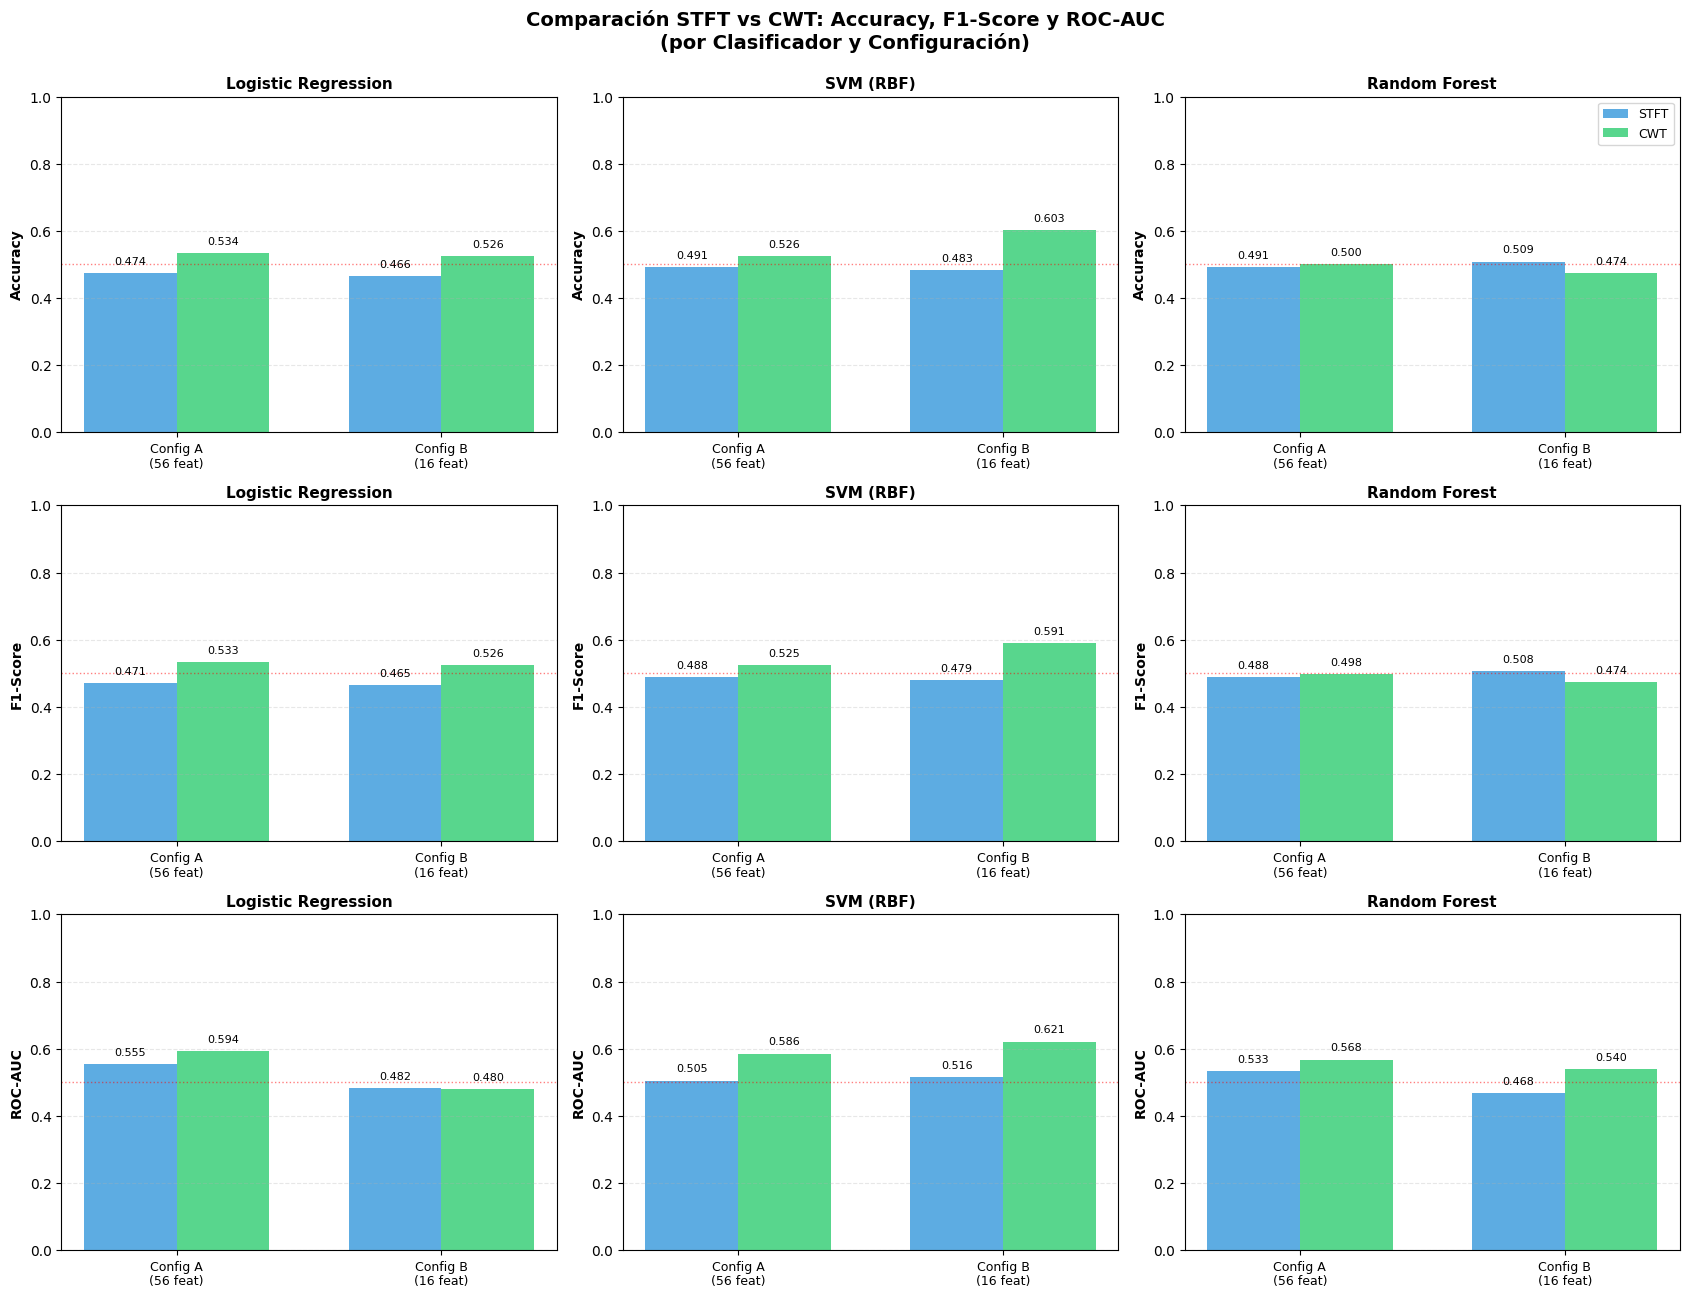

✓ Gráficos comparativos (9 paneles) completados


In [8]:
## Gráficos comparativos: STFT vs CWT por métrica, clasificador y configuración

fig, axes = plt.subplots(3, 3, figsize=(17, 13))
fig.suptitle('Comparación STFT vs CWT: Accuracy, F1-Score y ROC-AUC\n(por Clasificador y Configuración)', 
             fontsize=14, fontweight='bold', y=0.995)

metrics = ['Accuracy', 'F1-Score', 'ROC-AUC']
classifiers_list = list(classifiers.keys())
configs = ['A (56 features)', 'B (16 features)']

# Para cada métrica (filas)
for metric_idx, metric in enumerate(metrics):
    # Para cada clasificador (columnas)
    for clf_idx, clf_name in enumerate(classifiers_list):
        ax = axes[metric_idx, clf_idx]
        
        # Preparar datos para este clasificador y métrica
        subset = results_numeric_df[results_numeric_df['Clasificador'] == clf_name]
        
        x_pos = np.arange(len(configs))
        width = 0.35
        
        stft_vals = []
        cwt_vals = []
        
        for config in configs:
            config_data = subset[subset['Config'] == config]
            stft_val = config_data[config_data['Técnica'] == 'STFT'][metric].values[0]
            cwt_val = config_data[config_data['Técnica'] == 'CWT'][metric].values[0]
            stft_vals.append(stft_val)
            cwt_vals.append(cwt_val)
        
        # Graficar barras
        bars1 = ax.bar(x_pos - width/2, stft_vals, width, label='STFT', alpha=0.8, color='#3498db')
        bars2 = ax.bar(x_pos + width/2, cwt_vals, width, label='CWT', alpha=0.8, color='#2ecc71')
        
        # Configuración del eje
        ax.set_ylabel(metric, fontsize=10, fontweight='bold')
        ax.set_title(f'{clf_name}', fontsize=11, fontweight='bold')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(['Config A\n(56 feat)', 'Config B\n(16 feat)'], fontsize=9)
        ax.set_ylim([0.0, 1.0])
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.axhline(y=0.5, color='red', linestyle=':', alpha=0.5, linewidth=1)
        
        # Leyenda solo en el primer gráfico
        if clf_idx == 2 and metric_idx == 0:
            ax.legend(loc='upper right', fontsize=9)
        
        # Agregar valores en las barras
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                       f'{height:.3f}',
                       ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("✓ Gráficos comparativos (9 paneles) completados")

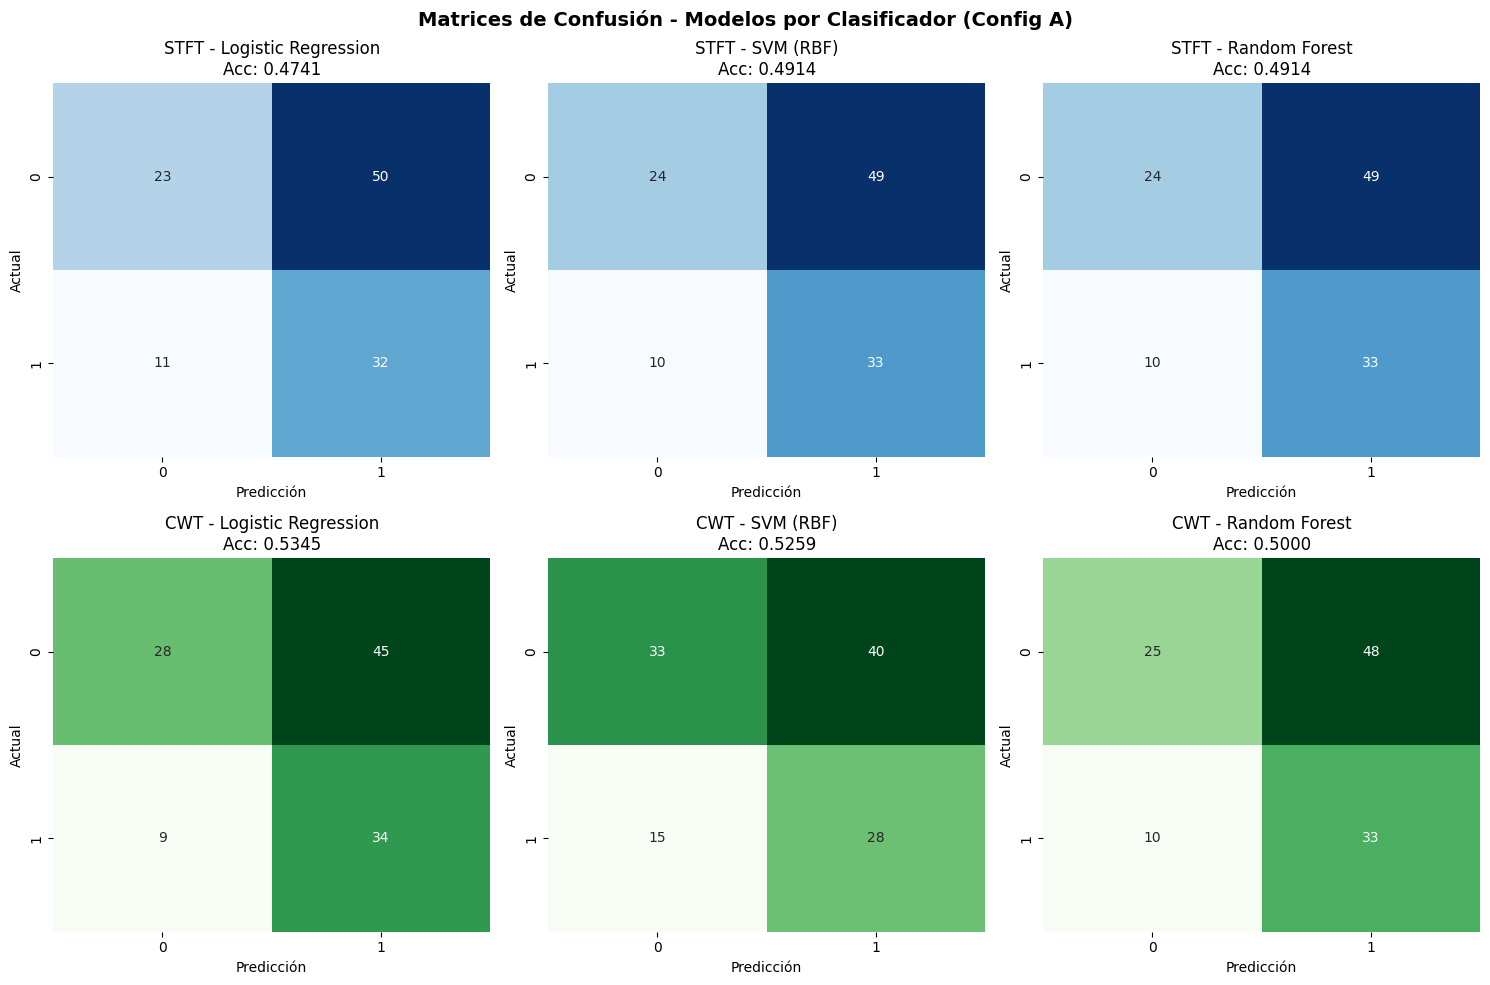

✓ Matrices de confusión graficadas


In [9]:
## Visualización: Matrices de Confusión para mejores modelos

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Matrices de Confusión - Modelos por Clasificador (Config A)', fontsize=14, fontweight='bold')

classifiers_list = list(classifiers.keys())

for idx, clf_name in enumerate(classifiers_list):
    # Fila 0: STFT Config A
    row = 0
    ax = axes[row, idx]
    stft_result = next(r for r in results if r['Técnica'] == 'STFT' and 
                                              r['Config'] == 'A (56 features)' and 
                                              r['Clasificador'] == clf_name)
    cm = stft_result['CM']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f"STFT - {clf_name}\nAcc: {stft_result['Accuracy']:.4f}")
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicción')
    
    # Fila 1: CWT Config A
    row = 1
    ax = axes[row, idx]
    cwt_result = next(r for r in results if r['Técnica'] == 'CWT' and 
                                            r['Config'] == 'A (56 features)' and 
                                            r['Clasificador'] == clf_name)
    cm = cwt_result['CM']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax, cbar=False)
    ax.set_title(f"CWT - {clf_name}\nAcc: {cwt_result['Accuracy']:.4f}")
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicción')

plt.tight_layout()
plt.show()

print("✓ Matrices de confusión graficadas")

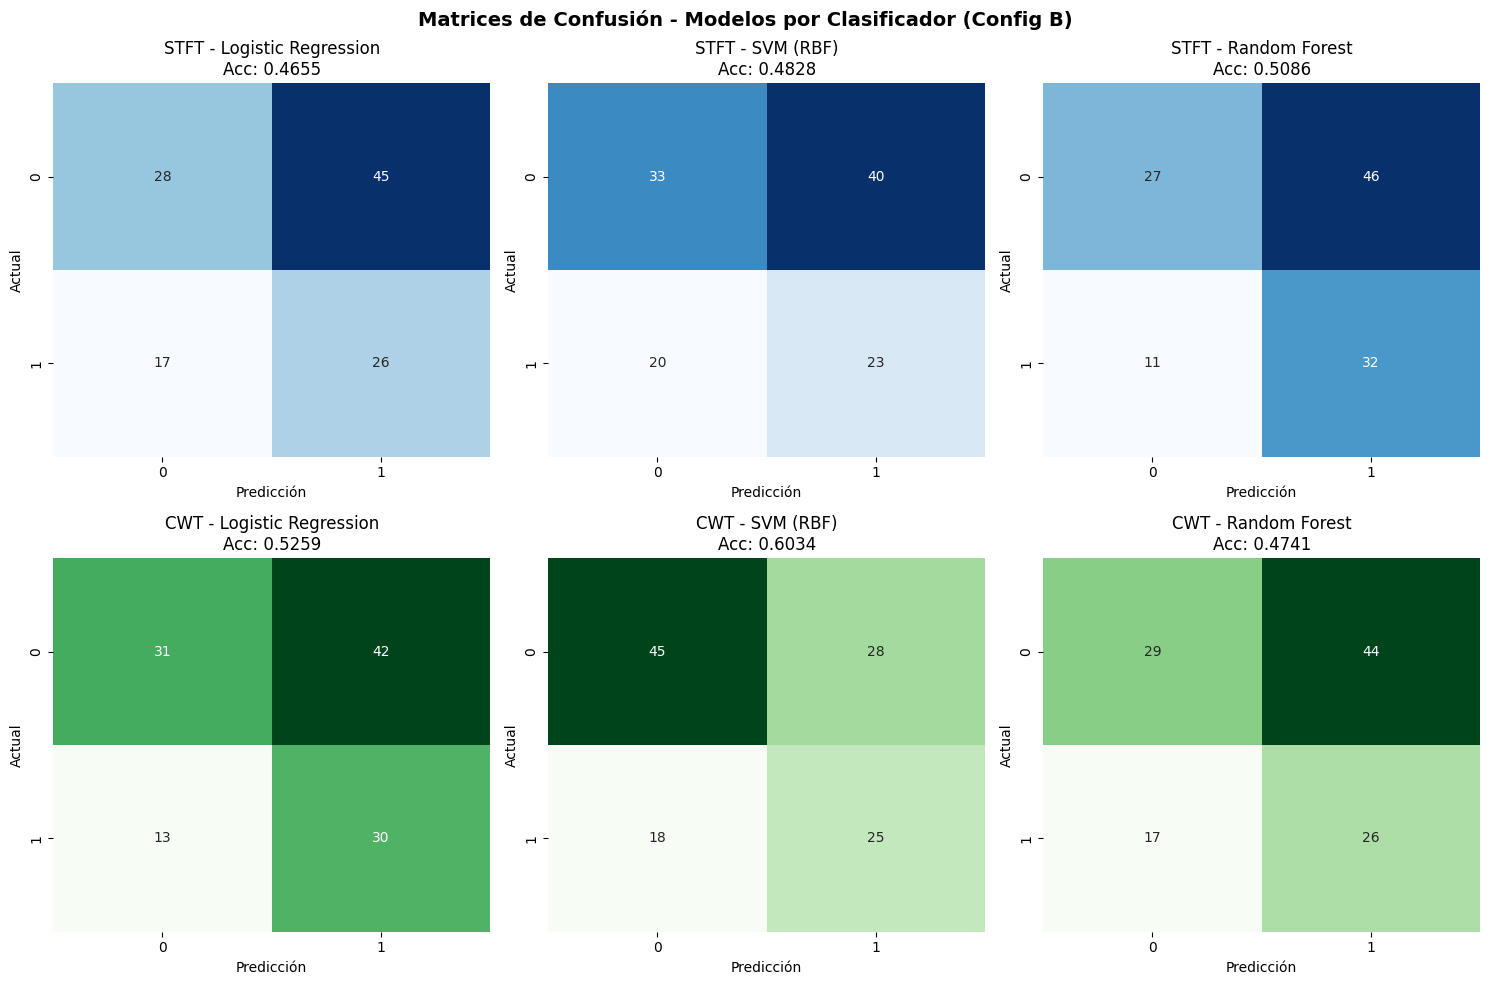

✓ Matrices de confusión graficadas


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Matrices de Confusión - Modelos por Clasificador (Config B)', fontsize=14, fontweight='bold')

classifiers_list = list(classifiers.keys())

for idx, clf_name in enumerate(classifiers_list):
    # Fila 0: STFT Config B
    row = 0
    ax = axes[row, idx]
    stft_result = next(r for r in results if r['Técnica'] == 'STFT' and 
                                              r['Config'] == 'B (16 features)' and 
                                              r['Clasificador'] == clf_name)
    cm = stft_result['CM']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f"STFT - {clf_name}\nAcc: {stft_result['Accuracy']:.4f}")
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicción')
    
    # Fila 1: CWT Config B
    row = 1
    ax = axes[row, idx]
    cwt_result = next(r for r in results if r['Técnica'] == 'CWT' and 
                                            r['Config'] == 'B (16 features)' and 
                                            r['Clasificador'] == clf_name)
    cm = cwt_result['CM']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax, cbar=False)
    ax.set_title(f"CWT - {clf_name}\nAcc: {cwt_result['Accuracy']:.4f}")
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicción')

plt.tight_layout()
plt.show()

print("✓ Matrices de confusión graficadas")

# Sección 3: Importancia de Features

Análisis del Random Forest para identificar qué canales contribuyen más a la clasificación y si dominan los canales fisiológicamente relevantes (O1, O2, P7, P8).

In [11]:
## Importancia de features - Random Forest (CWT Config A)

# Obtener el modelo Random Forest entrenado con CWT Config A
rf_cwt_a_result = next(r for r in results if r['Técnica'] == 'CWT' and 
                                              r['Config'] == 'A (56 features)' and 
                                              r['Clasificador'] == 'Random Forest')
rf_model = rf_cwt_a_result['model']

# Obtener importancia de features
feature_importance = rf_model.feature_importances_

# Mapear importancia a nombres de features (Config A)
idx_a_list = idx_config_a
feature_names_a = [feature_names[i] for i in idx_a_list]

# Crear DataFrame de importancia
importance_df = pd.DataFrame({
    'Feature': feature_names_a,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

# Extraer canal de cada feature (ej: "AF3_alpha_abs" → "AF3")
importance_df['Canal'] = importance_df['Feature'].str.split('_').str[0]
importance_df['Tipo'] = importance_df['Feature'].str.split('_').str[1] + '_' + importance_df['Feature'].str.split('_').str[2]

print("=" * 80)
print("IMPORTANCIA DE FEATURES - Random Forest (CWT, Config A)")
print("=" * 80)
print("\nTop 15 features más importantes:\n")
print(importance_df.head(15).to_string(index=False))

# Agrupar importancia por canal
canal_importance = importance_df.groupby('Canal')['Importance'].sum().sort_values(ascending=False)

print("\n\nIMPORTANCIA POR CANAL (suma de todas las features del canal):\n")
print(canal_importance.to_string())

# Identificar canales "alfa" (O1, O2, P7, P8)
canales_alfa_list = ['O1', 'O2', 'P7', 'P8']
importancia_alfa = canal_importance[canal_importance.index.isin(canales_alfa_list)].sum()
importancia_total = canal_importance.sum()
pct_alfa = importancia_alfa / importancia_total * 100

print(f"\n\nANÁLISIS TOPOGRÁFICO:")
print(f"  Importancia en canales ALFA (O1, O2, P7, P8): {importancia_alfa:.4f} ({pct_alfa:.1f}%)")
print(f"  Importancia en otros canales: {importancia_total - importancia_alfa:.4f} ({100-pct_alfa:.1f}%)")


IMPORTANCIA DE FEATURES - Random Forest (CWT, Config A)

Top 15 features más importantes:

      Feature  Importance Canal      Tipo
   T7_entropy    0.053974    T7       NaN
       F7_cog    0.032739    F7       NaN
 F8_alpha_abs    0.032580    F8 alpha_abs
   F7_entropy    0.032410    F7       NaN
  AF3_entropy    0.032170   AF3       NaN
   O2_entropy    0.032146    O2       NaN
AF3_alpha_rel    0.031087   AF3 alpha_rel
   P8_entropy    0.030731    P8       NaN
       T8_cog    0.028189    T8       NaN
 F7_alpha_rel    0.028101    F7 alpha_rel
 T7_alpha_rel    0.027066    T7 alpha_rel
 P8_alpha_rel    0.025755    P8 alpha_rel
       P8_cog    0.025137    P8       NaN
 O2_alpha_abs    0.023071    O2 alpha_abs
       O2_cog    0.022496    O2       NaN


IMPORTANCIA POR CANAL (suma de todas las features del canal):

Canal
T7     0.119114
F7     0.114519
O2     0.093065
P8     0.092015
AF3    0.083816
F3     0.073913
F8     0.071345
T8     0.059714
AF4    0.057502
F4     0.053826
FC6   

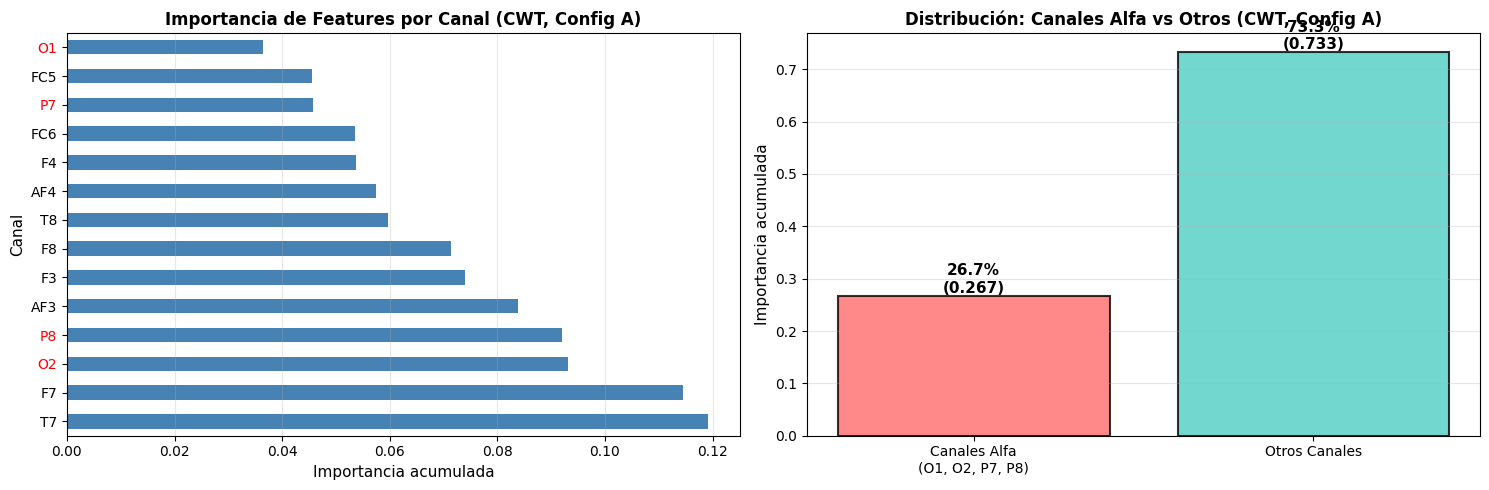

✓ Gráficos completados


In [12]:
## Visualización: Importancia de features por canal (gráfico de barras)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Importancia por canal
canal_importance.plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_xlabel('Importancia acumulada', fontsize=11)
ax1.set_ylabel('Canal', fontsize=11)
ax1.set_title('Importancia de Features por Canal (CWT, Config A)', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Colorear canales alfa de diferente color
canales_en_grafico = ax1.get_yticklabels()
for i, label in enumerate(canales_en_grafico):
    canal = label.get_text()
    if canal in canales_alfa_list:
        ax1.get_yticklabels()[i].set_color('red')

# Gráfico 2: Comparación Alfa vs Otros
categorias = ['Canales Alfa\n(O1, O2, P7, P8)', 'Otros Canales']
importancias = [importancia_alfa, importancia_total - importancia_alfa]
colores = ['#ff6b6b', '#4ecdc4']

bars = ax2.bar(categorias, importancias, color=colores, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Importancia acumulada', fontsize=11)
ax2.set_title('Distribución: Canales Alfa vs Otros (CWT, Config A)', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Agregar porcentajes en las barras
for bar, (cat, val, pct) in zip(bars, zip(categorias, importancias, [pct_alfa, 100-pct_alfa])):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{pct:.1f}%\n({val:.3f})',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Gráficos completados")

# Sección 4: Síntesis y conclusiones

Los resultados muestran que las características obtenidas mediante CWT lograron un mejor desempeño que las derivadas de STFT para la clasificación de estados de ojos abiertos y ojos cerrados. La mejor configuración correspondió a CWT con 16 características y un clasificador SVM, alcanzando una accuracy de 0.6034.

El análisis de las matrices de confusión mostró que la mayoría de las configuraciones evaluadas tendieron a favorecer una de las clases, produciendo una distribución desigual de errores. En varios casos se observó una mayor cantidad de muestras clasificadas como una misma clase, independientemente de su etiqueta real.

El análisis de importancia de características realizado mediante Random Forest mostró una mayor contribución de canales frontales y temporales que de canales occipitales asociados al ritmo alfa. Esto sugiere que la mejora obtenida por CWT no puede atribuirse únicamente a una mejor representación del ritmo alfa, sino que también podría estar relacionada con una mayor sensibilidad a artefactos fisiológicos o componentes transitorios de la señal.

En conjunto, los resultados indican que la combinación CWT + SVM + 16 características fue la más efectiva para esta tarea, aunque la información utilizada por el clasificador parece provenir de múltiples regiones de la señal EEG y no exclusivamente de la actividad alfa esperada para la condición de ojos cerrados.